In [52]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import pickle
import csv
from scipy import integrate
from car_park_functions import *
import math

In [53]:
bolTrainagain = False # will try to load data if false 

In [54]:
available_parkings = ['Vilanova', 'SantSadurni', 'SantBoi', 'QuatreCamins',
                      'Cerdanyola','Granollers','Martorell','Mollet',
                      'SantQuirze','PratDelLlobregat']
df_column_name=['Parking Vilanova Renfe','Parking Sant Sadurní Renfe','Parking Sant Boi de Llobregat',
              'Parking Quatre Camins','Cerdanyola Universitat Renfe','Parking Granollers Renfe',
                'Parking Martorell FGC','Parking Mollet Renfe','Parking Sant Quirze FGC',
               'Parking Prat del Ll.']
current_parking_ix=7
# problems on Weekend with 2 SantBoi, 4 Cerdanyola, 
# bad data: 6 Martorell, 8 SantQuirze DO NOT USE
#good 0 Vilanova, 1 SantSadurni, 3 QuatreCamins, 5 Granollers, 7 Mollet, 9 PratDelLlobregat 
# needs treshold  3 QuatreCamins, 2 SantBoi,  7 Mollet 
current_parking = available_parkings[current_parking_ix]
current_column_name=df_column_name[current_parking_ix]


# loadind data:
    # Getting back the objects:
with open('data/'+current_parking+'_normalized.pkl','rb') as f:  # Python 3: open(..., 'rb')
    df_normalized, weekday_offset, friday_offset,  weekend_offset, max_value= pickle.load(f)
    f.close()
axis_ylim = max_value+20

df_training, df_testing = split_data(df_normalized, 3)



df_mean_areas = df_training.groupby(['Profile_3'], as_index=False).mean() 
df_mean_areas[['Profile_3', 'Area']]

friday_area = df_mean_areas.iloc[0]['Area']
weekday_area = df_mean_areas.iloc[1]['Area']
weekend_area = df_mean_areas.iloc[2]['Area']

friday_max = df_mean_areas.iloc[0]['MaxV']
weekday_max = df_mean_areas.iloc[1]['MaxV']
weekend_max = df_mean_areas.iloc[2]['MaxV']

print('Weekday area: ' , weekday_area)
print('Friday area: ' , friday_area)
print('Weekend area: ' , weekend_area)

print('Weekday maximum: ' , weekday_max)
print('Friday maximum: ' , friday_max)
print('Weekend maximum: ' , weekend_max)

Weekday area:  4929.808641975347
Friday area:  4763.91666666666
Weekend area:  1473.9833333333395
Weekday maximum:  205.07407407407408
Friday maximum:  198.16666666666666
Weekend maximum:  65.1


## MATHEMATICAL MODEL - CDF Subtraction

In [55]:
import matplotlib.pyplot as plt 
available_parkings = ['Vilanova', 'SantSadurni', 'SantBoi', 'QuatreCamins',
                      'Cerdanyola','Granollers','Mollet','PratDelLlobregat']
fsize=20

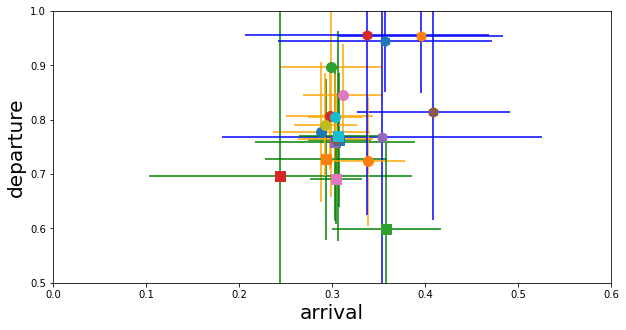

In [56]:
fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10,5), sharey=True)
for current_parking_ix in range(8):
    current_parking = available_parkings[current_parking_ix]
    with open('data/'+current_parking+'_modelFit.pkl','rb') as f:  # Python 3: open(..., 'rb')
        [optimal_params_weekdaytn, errors_wd, optimal_params_fridaytn, 
         errors_fr, optimal_params_weekendtn, errors_we]= pickle.load(f)
    f.close()
    mu_aWD=optimal_params_weekdaytn.x[0]
    si_aWD=optimal_params_weekdaytn.x[1]
    mu_dWD=optimal_params_weekdaytn.x[2]
    si_dWD=optimal_params_weekdaytn.x[3]

    mu_aFR=optimal_params_fridaytn.x[0]
    si_aFR=optimal_params_fridaytn.x[1]
    mu_dFR=optimal_params_fridaytn.x[2]
    si_dFR=optimal_params_fridaytn.x[3]

    mu_aWE=optimal_params_weekendtn.x[0]
    si_aWE=optimal_params_weekendtn.x[1]
    mu_dWE=optimal_params_weekendtn.x[2]
    si_dWE=optimal_params_weekendtn.x[3]
    
    ax2.plot(mu_aWD,mu_dWD,'o',markersize=10)
    ax2.errorbar(mu_aWD,mu_dWD,xerr=si_aWD,yerr=si_dWD,color='orange')
    #ax2.plot([mu_aWD+si_aWD, mu_aWD-si_aWD],[mu_dWD, mu_dWD],'-')
    
    ax2.plot(mu_aFR,mu_dFR,'s',markersize=10)
    ax2.errorbar(mu_aFR,mu_dFR,xerr=si_aFR,yerr=si_dFR,color='green')
    #ax2.plot([mu_aWD, mu_aWD],[mu_dWD+si_dWD, mu_dWD-si_dWD],'-')
    #ax2.plot(mu_aFR,mu_dFR,'s')
    #ax2.plot(mu_aWE,mu_dWE,'p')
    ax2.plot(mu_aWE,mu_dWE,'h',markersize=10)
    ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='blue')
    
    
    ax2.set_xlim([0,0.6])
    ax2.set_ylim([0.5,1])
    ax2.set_ylabel('departure', fontsize = fsize)
    ax2.set_xlabel('arrival', fontsize = fsize)

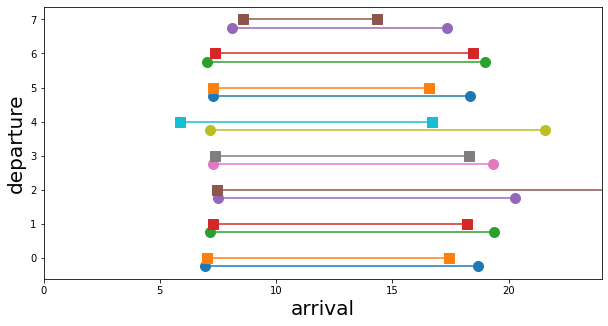

In [57]:
fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10,5), sharey=True)


num_stations=len(available_parkings)
mu_aWD = np.zeros(num_stations)
si_aWD = np.zeros(num_stations)
mu_dWD = np.zeros(num_stations)
si_dWD = np.zeros(num_stations)

mu_aFR = np.zeros(num_stations)
si_aFR = np.zeros(num_stations)
mu_dFR = np.zeros(num_stations)
si_dFR = np.zeros(num_stations)

mu_aWE = np.zeros(num_stations)
si_aWE = np.zeros(num_stations)
mu_dWE = np.zeros(num_stations)
si_dWE = np.zeros(num_stations)

i=0
for current_parking_ix in range(num_stations):

    current_parking = available_parkings[current_parking_ix]
    with open('data/'+current_parking+'_modelFit.pkl','rb') as f:  # Python 3: open(..., 'rb')
        [optimal_params_weekdaytn, errors_wd, optimal_params_fridaytn, 
         errors_fr, optimal_params_weekendtn, errors_we]= pickle.load(f)
    f.close()
    mu_aWD[i]=optimal_params_weekdaytn.x[0]
    si_aWD[i]=optimal_params_weekdaytn.x[1]
    mu_dWD[i]=optimal_params_weekdaytn.x[2]
    si_dWD[i]=optimal_params_weekdaytn.x[3]

    mu_aFR[i]=optimal_params_fridaytn.x[0]
    si_aFR[i]=optimal_params_fridaytn.x[1]
    mu_dFR[i]=optimal_params_fridaytn.x[2]
    si_dFR[i]=optimal_params_fridaytn.x[3]

    mu_aWE[i]=optimal_params_weekendtn.x[0]
    si_aWE[i]=optimal_params_weekendtn.x[1]
    mu_dWE[i]=optimal_params_weekendtn.x[2]
    si_dWE[i]=optimal_params_weekendtn.x[3]
    
    ax2.plot([mu_aWD[i]*24, mu_dWD[i]*24],[i-0.25, i-0.25],'-o',markersize=10)
    #ax2.errorbar(mu_aWD,mu_dWD,xerr=si_aWD,yerr=si_dWD,color='orange')
    #ax2.plot([mu_aWD+si_aWD, mu_aWD-si_aWD],[mu_dWD, mu_dWD],'-')
    
    ax2.plot([mu_aFR[i]*24, mu_dFR[i]*24],[i, i],'-s',markersize=10)
    #ax2.errorbar(mu_aFR,mu_dFR,xerr=si_aFR,yerr=si_dFR,color='green')
    #ax2.plot([mu_aWD, mu_aWD],[mu_dWD+si_dWD, mu_dWD-si_dWD],'-')
    #ax2.plot(mu_aFR,mu_dFR,'s')
    #ax2.plot(mu_aWE,mu_dWE,'p')
    #ax2.plot([mu_aWE*24,mu_dWE*24],[i+0.25, i+0.25],'-h',markersize=10)
    #ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='blue')
    
    
    ax2.set_xlim([0,24])
    #ax2.set_ylim([0.5,1])
    ax2.set_ylabel('departure', fontsize = fsize)
    ax2.set_xlabel('arrival', fontsize = fsize)
    
    i=i+1

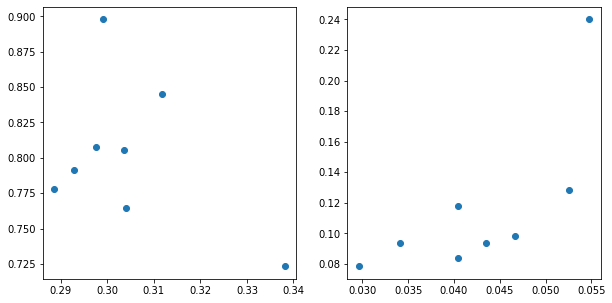

In [58]:
fig, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharey=False)
ax2[0].plot(mu_aWD,mu_dWD,'o')
ax2[1].plot(si_aWD,si_dWD,'o')

In [59]:
import scipy 
r, p = scipy.stats.pearsonr(mu_aWD,mu_dWD)
print(r)
print(p)

-0.41954779417474775
0.3007844794052553


In [60]:
r, p = scipy.stats.pearsonr(mu_aWD[:-1],mu_dWD[:-1])
print(r)
print(p)

0.31024059359641387
0.4982952696812208


In [61]:
mu_aWD

array([0.28858668, 0.29758856, 0.31170596, 0.30350063, 0.29906572,
       0.30400155, 0.29291107, 0.3381864 ])

In [62]:
r, p = scipy.stats.pearsonr(si_aWD,si_dWD)
print(r)
print(p)

0.7258488658924539
0.04150134843341372


In [63]:
def plot_model_tn_offset(axh,loc_ar=.3, scale_ar=.05, loc_de=.8, scale_de=.1,offset=0,mylabelC=None):
    
    default_color_cycle=[u'#1f77b4', u'#ff7f0e', u'#2ca02c', u'#d62728', u'#9467bd', u'#8c564b', u'#e377c2', u'#7f7f7f', u'#bcbd22', u'#17becf']

    # arrivals
    a_ar = -loc_ar/scale_ar
    b_ar = (1-loc_ar)/scale_ar

    # departures
    a_de = -loc_de/scale_de
    b_de = (1-loc_de)/scale_de

    time = np.linspace(0,23.5,48)
    time_tn=time/24

    pdf_ar = truncnorm.pdf(time_tn, a_ar, b_ar, loc=loc_ar, scale=scale_ar)
    pdf_de = truncnorm.pdf(time_tn, a_de, b_de, loc=loc_de, scale=scale_de)
    cdf_ar = truncnorm.cdf(time_tn, a_ar, b_ar, loc=loc_ar, scale=scale_ar)
    cdf_de = truncnorm.cdf(time_tn, a_de, b_de, loc=loc_de, scale=scale_de)

    #fig, ax = plt.subplots(2)
    #ax[0].plot(time, pdf_ar, '-b')
    #ax[0].plot(time, pdf_de, '-r')
    #ax[0].set_title('pdfs')

    #ax[1].plot(time, cdf_ar , '--b')
    #ax[1].plot(time, cdf_de, '--r')
    axh.plot(time, cdf_ar-cdf_de+offset, color=default_color_cycle[i],label=mylabelC)
    #ax[1].set_title('cdfs')

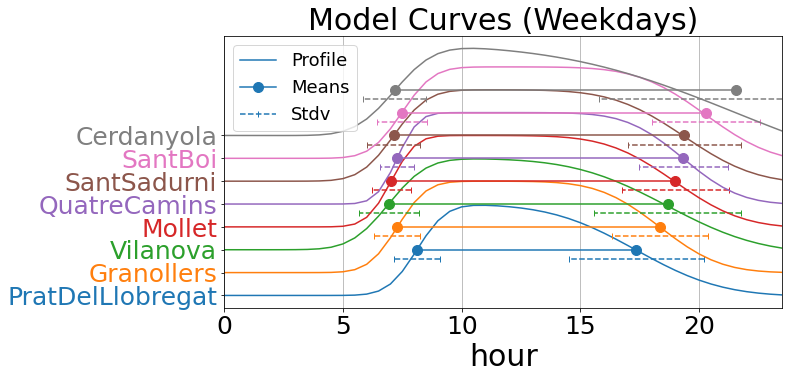

In [64]:
fsize=30
fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
i=0;


default_color_cycle=[u'#1f77b4', u'#ff7f0e', u'#2ca02c', u'#d62728', u'#9467bd', u'#8c564b', u'#e377c2', u'#7f7f7f', u'#bcbd22', u'#17becf']
#reindex = np.flip((mu_dWD-mu_aWD).argsort())
reindex = (mu_dWD-mu_aWD).argsort()
mu_aWDr = mu_aWD[reindex]
si_aWDr = si_aWD[reindex]
mu_dWDr = mu_dWD[reindex]
si_dWDr = si_dWD[reindex]

available_parkings_reindexed = [available_parkings[i] for i in reindex]

for current_parking_ix in range(8):
    if i==0:
        mylabelM="Means"
        mylabelS="Stdv"
        mylabelC="Profile"
    else:
        mylabelM=None 
        mylabelS=None 
        mylabelC=None
    
    #ax2.plot([mu_aWD*24, mu_dWD*24],[i-0.25, i-0.25],'-o',markersize=10)
    #ax2.errorbar(mu_aWD,mu_dWD,xerr=si_aWD,yerr=si_dWD,color='orange')
    #ax2.plot([mu_aWD+si_aWD, mu_aWD-si_aWD],[mu_dWD, mu_dWD],'-')
    
    #ax2.plot([mu_aFR*24, mu_dFR*24],[i, i],'-s',markersize=10)
    #ax2.errorbar(mu_aFR,mu_dFR,xerr=si_aFR,yerr=si_dFR,color='green')
    #ax2.plot([mu_aWD, mu_aWD],[mu_dWD+si_dWD, mu_dWD-si_dWD],'-')
    #ax2.plot(mu_aFR,mu_dFR,'s')
    #ax2.plot(mu_aWE,mu_dWE,'p')
    #ax2.plot([mu_aWE*24,mu_dWE*24],[i+0.25, i+0.25],'-h',markersize=10)
    #ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='blue')
    plot_model_tn_offset(ax2,mu_aWDr[i],si_aWDr[i],mu_dWDr[i],si_dWDr[i],i/4,mylabelC)
    ax2.plot([mu_aWDr[i]*24, mu_dWDr[i]*24],[i/4+.5, i/4+.5],'-o',markersize=10,label=mylabelM)
    ax2.plot([(mu_aWDr[i]+si_aWDr[i])*24, (mu_aWDr[i]-si_aWDr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
             '--|',color=default_color_cycle[i],label=mylabelS)
    ax2.plot([(mu_dWDr[i]+si_dWDr[i])*24, (mu_dWDr[i]-si_dWDr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
             '--|',color=default_color_cycle[i]) 
    i=i+1
ax2.set_xlim([0,24])
ax2.set_yticks(np.arange(0, 2, .25))
ax2.set_yticklabels(available_parkings_reindexed, fontsize=fsize)
ax2.tick_params(labelsize=fsize-5)
[t.set_color(i) for (i,t) in zip(default_color_cycle,ax2.yaxis.get_ticklabels())]
#ax2.set_ylim([0.5,1])
ax2.set_xlim([0,23.5])
#ax2.set_ylabel('departure', fontsize = fsize)
ax2.set_xlabel('hour', fontsize = fsize)
#ax2.grid(True)
ax2.xaxis.grid(True)
ax2.legend( fontsize = fsize-12)
ax2.set_title('Model Curves (Weekdays)', fontsize = fsize);
    #ax2.grid(which='major',linestyle='dotted')
#fig.savefig('Model_curves_w_ErrorbarsWD.pdf',bbox_inches='tight');

In [65]:
mu_dWDr*24

array([17.35772645, 18.34620451, 18.67231535, 18.98719184, 19.33872708,
       19.38344901, 20.29043924, 21.54930476])

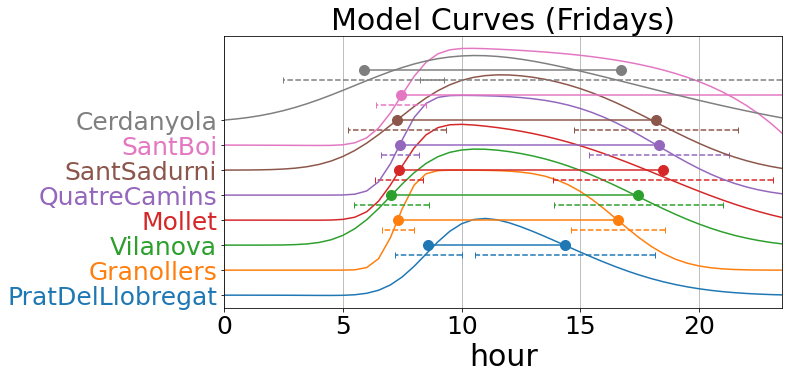

In [66]:
fsize=30
fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
i=0;


default_color_cycle=[u'#1f77b4', u'#ff7f0e', u'#2ca02c', u'#d62728', u'#9467bd', u'#8c564b', u'#e377c2', u'#7f7f7f', u'#bcbd22', u'#17becf']
#reindex = np.flip((mu_dFR-mu_aFR).argsort())
#reindex = (mu_dFR-mu_aFR).argsort()
mu_aFRr = mu_aFR[reindex]
si_aFRr = si_aFR[reindex]
mu_dFRr = mu_dFR[reindex]
si_dFRr = si_dFR[reindex]

available_parkings_reindexed = [available_parkings[i] for i in reindex]

for current_parking_ix in range(8):
    if i==0:
        mylabelM="Means"
        mylabelS="Stdv"
        mylabelC="Profile"
    else:
        mylabelM=None 
        mylabelS=None 
        mylabelC=None
    
    #ax2.plot([mu_aFR*24, mu_dFR*24],[i-0.25, i-0.25],'-o',markersize=10)
    #ax2.errorbar(mu_aFR,mu_dFR,xerr=si_aFR,yerr=si_dFR,color='orange')
    #ax2.plot([mu_aFR+si_aFR, mu_aFR-si_aFR],[mu_dFR, mu_dFR],'-')
    
    #ax2.plot([mu_aFR*24, mu_dFR*24],[i, i],'-s',markersize=10)
    #ax2.errorbar(mu_aFR,mu_dFR,xerr=si_aFR,yerr=si_dFR,color='green')
    #ax2.plot([mu_aFR, mu_aFR],[mu_dFR+si_dFR, mu_dFR-si_dFR],'-')
    #ax2.plot(mu_aFR,mu_dFR,'s')
    #ax2.plot(mu_aWE,mu_dWE,'p')
    #ax2.plot([mu_aWE*24,mu_dWE*24],[i+0.25, i+0.25],'-h',markersize=10)
    #ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='blue')
    plot_model_tn_offset(ax2,mu_aFRr[i],si_aFRr[i],mu_dFRr[i],si_dFRr[i],i/4,mylabelC)
    ax2.plot([mu_aFRr[i]*24, mu_dFRr[i]*24],[i/4+.5, i/4+.5],'-o',markersize=10,label=mylabelM)
    ax2.plot([(mu_aFRr[i]+si_aFRr[i])*24, (mu_aFRr[i]-si_aFRr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
             '--|',color=default_color_cycle[i],label=mylabelS)
    ax2.plot([(mu_dFRr[i]+si_dFRr[i])*24, (mu_dFRr[i]-si_dFRr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
             '--|',color=default_color_cycle[i]) 
    i=i+1
ax2.set_xlim([0,24])
ax2.set_yticks(np.arange(0, 2, .25))
ax2.set_yticklabels(available_parkings_reindexed, fontsize=fsize)
ax2.tick_params(labelsize=fsize-5)
[t.set_color(i) for (i,t) in zip(default_color_cycle,ax2.yaxis.get_ticklabels())]
#ax2.set_ylim([0.5,1])
ax2.set_xlim([0,23.5])
#ax2.set_ylabel('departure', fontsize = fsize)
ax2.set_xlabel('hour', fontsize = fsize)
#ax2.grid(True)
ax2.xaxis.grid(True)
#ax2.legend( fontsize = fsize-5)
ax2.set_title('Model Curves (Fridays)', fontsize = fsize);
    #ax2.grid(which='major',linestyle='dotted')
#fig.savefig('Model_curves_w_ErrorbarsFR.pdf',bbox_inches='tight');


In [67]:
mu_dFRr*24

array([  14.36096341,   16.5712169 ,   17.44708356,   18.48076054,
         18.31377199,   18.19991419, 6809.89006505,   16.69488877])

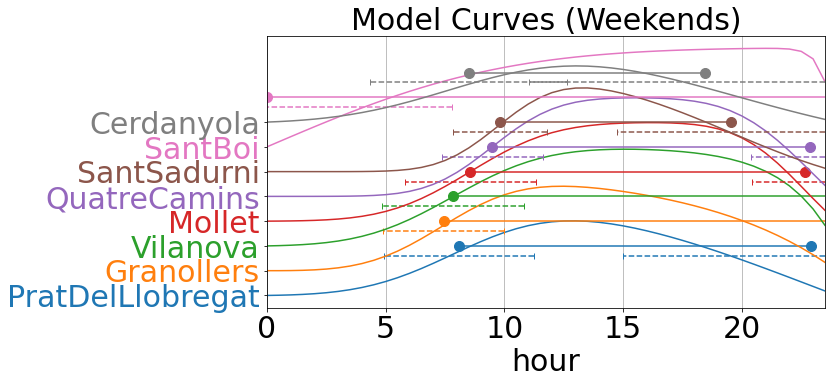

In [68]:
fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
i=0;


default_color_cycle=[u'#1f77b4', u'#ff7f0e', u'#2ca02c', u'#d62728', u'#9467bd', u'#8c564b', u'#e377c2', u'#7f7f7f', u'#bcbd22', u'#17becf']
#reindex = np.flip((mu_dWE-mu_aWE).argsort())
#reindex = (mu_dWE-mu_aWE).argsort()
mu_aWEr = mu_aWE[reindex]
si_aWEr = si_aWE[reindex]
mu_dWEr = mu_dWE[reindex]
si_dWEr = si_dWE[reindex]

available_parkings_reindexed = [available_parkings[i] for i in reindex]

for current_parking_ix in range(8):
    if i==0:
        mylabelM="Means"
        mylabelS="Stdv"
        mylabelC="Profile"
    else:
        mylabelM=None 
        mylabelS=None 
        mylabelC=None
    
    #ax2.plot([mu_aWE*24, mu_dWE*24],[i-0.25, i-0.25],'-o',markersize=10)
    #ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='orange')
    #ax2.plot([mu_aWE+si_aWE, mu_aWE-si_aWE],[mu_dWE, mu_dWE],'-')
    
    #ax2.plot([mu_aWE*24, mu_dWE*24],[i, i],'-s',markersize=10)
    #ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='green')
    #ax2.plot([mu_aWE, mu_aWE],[mu_dWE+si_dWE, mu_dWE-si_dWE],'-')
    #ax2.plot(mu_aWE,mu_dWE,'s')
    #ax2.plot(mu_aWE,mu_dWE,'p')
    #ax2.plot([mu_aWE*24,mu_dWE*24],[i+0.25, i+0.25],'-h',markersize=10)
    #ax2.errorbar(mu_aWE,mu_dWE,xerr=si_aWE,yerr=si_dWE,color='blue')
    plot_model_tn_offset(ax2,mu_aWEr[i],si_aWEr[i],mu_dWEr[i],si_dWEr[i],i/4,mylabelC)
    ax2.plot([mu_aWEr[i]*24, mu_dWEr[i]*24],[i/4+.5, i/4+.5],'-o',markersize=10,label=mylabelM)
    ax2.plot([(mu_aWEr[i]+si_aWEr[i])*24, (mu_aWEr[i]-si_aWEr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
             '--|',color=default_color_cycle[i],label=mylabelS)
    ax2.plot([(mu_dWEr[i]+si_dWEr[i])*24, (mu_dWEr[i]-si_dWEr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
             '--|',color=default_color_cycle[i]) 
    i=i+1
ax2.set_xlim([0,24])
ax2.set_yticks(np.arange(0, 2, .25))
ax2.set_yticklabels(available_parkings_reindexed, fontsize=fsize)
ax2.tick_params(labelsize=fsize)
[t.set_color(i) for (i,t) in zip(default_color_cycle,ax2.yaxis.get_ticklabels())]
#ax2.set_ylim([0.5,1])
ax2.set_xlim([0,23.5])
#ax2.set_ylabel('departure', fontsize = fsize)
ax2.set_xlabel('hour', fontsize = fsize)
#ax2.grid(True)
ax2.xaxis.grid(True)
#ax2.legend( fontsize = fsize-5)
ax2.set_title('Model Curves (Weekends)', fontsize = fsize);
    #ax2.grid(which='major',linestyle='dotted')
plt.show()
#fig.savefig('Model_curves_w_ErrorbarsWE.pdf',bbox_inches='tight');

In [69]:
i=0;
for current_parking_ix in range(8):
    print(available_parkings_reindexed[i] + " & " +
          "{:02.0f}".format(np.floor(mu_aWDr[i]*24))+":{:02.0f}".format((mu_aWDr[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(si_aWDr[i]*24))+"h{:02.0f}".format((si_aWDr[i]*24 %1)*60 ) +" &  " + 
          "{:02.0f}".format(np.floor(mu_dWDr[i]*24))+":{:02.0f}".format((mu_dWDr[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(si_dWDr[i]*24))+"h{:02.0f}".format((si_dWDr[i]*24 %1)*60 ) +" &  " + 
          "{:02.0f}".format(np.floor(mu_aFRr[i]*24))+":{:02.0f}".format((mu_aFRr[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(si_aFRr[i]*24))+"h{:02.0f}".format((si_aFRr[i]*24 %1)*60 ) +" &  " + 
          "{:02.0f}".format(np.floor(mu_dFRr[i]*24))+":{:02.0f}".format((mu_dFRr[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(si_dFRr[i]*24))+"h{:02.0f}".format((si_dFRr[i]*24 %1)*60 ) +" &  " + 
          "{:02.0f}".format(np.floor(mu_aWEr[i]*24))+":{:02.0f}".format((mu_aWEr[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(si_aWEr[i]*24))+"h{:02.0f}".format((si_aWEr[i]*24 %1)*60 ) +" &  " + 
          "{:02.0f}".format(np.floor(mu_dWEr[i]*24))+":{:02.0f}".format((mu_dWEr[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(si_dWEr[i]*24))+"h{:02.0f}".format((si_dWEr[i]*24 %1)*60 ) + " \\")
    #ax2.plot([mu_aWEr[i]*24, mu_dWEr[i]*24],[i/4+.5, i/4+.5],'-o',markersize=10,label=mylabelM)
    #ax2.plot([(mu_aWEr[i]+si_aWEr[i])*24, (mu_aWEr[i]-si_aWEr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
    #         '--|',color=default_color_cycle[i],label=mylabelS)
    #ax2.plot([(mu_dWEr[i]+si_dWEr[i])*24, (mu_dWEr[i]-si_dWEr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
    #         '--|',color=default_color_cycle[i]) 
    i=i+1

PratDelLlobregat & 08:07 $\pm$00h58 &  17:21 $\pm$02h50 &  08:36 $\pm$01h25 &  14:22 $\pm$03h48 &  08:06 $\pm$03h09 &  22:55 $\pm$07h54 \
Granollers & 07:18 $\pm$00h58 &  18:21 $\pm$02h01 &  07:18 $\pm$00h40 &  16:34 $\pm$01h59 &  07:26 $\pm$02h34 &  10786:37 $\pm$249h47 \
Vilanova & 06:56 $\pm$01h16 &  18:40 $\pm$03h05 &  07:02 $\pm$01h35 &  17:27 $\pm$03h33 &  07:50 $\pm$03h00 &  248917:52 $\pm$730h15 \
Mollet & 07:02 $\pm$00h49 &  18:59 $\pm$02h15 &  07:22 $\pm$01h00 &  18:29 $\pm$04h39 &  08:34 $\pm$02h46 &  22:39 $\pm$02h13 \
QuatreCamins & 07:17 $\pm$00h43 &  19:20 $\pm$01h53 &  07:23 $\pm$00h48 &  18:19 $\pm$02h57 &  09:29 $\pm$02h08 &  22:53 $\pm$02h31 \
SantSadurni & 07:09 $\pm$01h07 &  19:23 $\pm$02h22 &  07:16 $\pm$02h04 &  18:12 $\pm$03h27 &  09:49 $\pm$01h58 &  19:32 $\pm$04h47 \
SantBoi & 07:29 $\pm$01h03 &  20:17 $\pm$02h15 &  07:27 $\pm$01h02 &  6809:53 $\pm$164h43 &  00:00 $\pm$07h47 &  33:11 $\pm$02h09 \
Cerdanyola & 07:11 $\pm$01h19 &  21:33 $\pm$05h46 &  05:52 $\pm$

In [70]:
mu_aWEr

array([0.33752738, 0.31005619, 0.32664733, 0.35668576, 0.39530175,
       0.40900653, 0.        , 0.35367938])

In [71]:
optimal_params_weekdaytn

 final_simplex: (array([[0.3381864 , 0.04045137, 0.7232386 , 0.11797305],
       [0.3381862 , 0.04045164, 0.72323844, 0.11797228],
       [0.33818601, 0.04045123, 0.7232393 , 0.11797216],
       [0.33818607, 0.04045126, 0.72323851, 0.11797316],
       [0.338186  , 0.04045165, 0.72323906, 0.11797262]]), array([0.04122178, 0.04122178, 0.04122178, 0.04122178, 0.04122178]))
           fun: 0.04122178324214991
       message: 'Optimization terminated successfully.'
          nfev: 242
           nit: 139
        status: 0
       success: True
             x: array([0.3381864 , 0.04045137, 0.7232386 , 0.11797305])

In [75]:
available_parkingsTH = ['SantSadurni', 'SantBoi', 'QuatreCamins','Mollet']
num_stationsTH=len(available_parkingsTH)   

muTH_aWD = np.zeros(num_stationsTH)
siTH_aWD = np.zeros(num_stationsTH)
muTH_dWD = np.zeros(num_stationsTH)
siTH_dWD = np.zeros(num_stationsTH)
TH_WD= np.zeros(num_stationsTH)

muTH_aFR = np.zeros(num_stationsTH)
siTH_aFR = np.zeros(num_stationsTH)
muTH_dFR = np.zeros(num_stationsTH)
siTH_dFR = np.zeros(num_stationsTH)
TH_FR= np.zeros(num_stationsTH)

i=0
for current_parkingTH_ix in range(num_stationsTH):
    
    current_parkingTH = available_parkingsTH[current_parkingTH_ix]
    with open('data/'+current_parkingTH+'_modelFitTH.pkl','rb') as f:  # Python 3: open(..., 'rb')
        [optimal_params_weekdaytn, errors_wd, optimal_params_fridaytn, 
         errors_fr, optimal_params_weekendtn, errors_we]= pickle.load(f)
    f.close()
    
    muTH_aWD[i]=optimal_params_weekdaytn.x[0]
    siTH_aWD[i]=optimal_params_weekdaytn.x[1]
    muTH_dWD[i]=optimal_params_weekdaytn.x[2]
    siTH_dWD[i]=optimal_params_weekdaytn.x[3]
    TH_WD[i]=np.mean(optimal_params_weekdaytn.x[4:])

    muTH_aFR[i]=optimal_params_fridaytn.x[0]
    siTH_aFR[i]=optimal_params_fridaytn.x[1]
    muTH_dFR[i]=optimal_params_fridaytn.x[2]
    siTH_dFR[i]=optimal_params_fridaytn.x[3]
    TH_FR[i]=np.mean(optimal_params_fridaytn.x[4:])
    print(optimal_params_fridaytn.x[4:])
    i=i+1

[1.1166977  0.36448835 0.62949741 0.90971054 0.59037469 0.39059415]
[0.14566305 0.1461362  0.11459842 0.1039323  0.10440853]
[0.68350776 0.82301888 0.87377744 0.68089001 0.68089114 0.68089001
 0.69284511]
[0.88433931 0.75313584 0.82026323 0.54323612 0.67382288 0.67382288]


In [73]:
TH_WD

array([0.7689989 , 0.75748758, 0.79580258, 0.80656781])

In [74]:
i=0;
for current_parkingTH_ix in range(num_stationsTH):
    print(available_parkingsTH[i] + " & " +
          "{:02.0f}".format(np.floor(muTH_aWD[i]*24))+":{:02.0f}".format((muTH_aWD[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(siTH_aWD[i]*24))+"h{:02.0f}".format((siTH_aWD[i]*24 %1)*60 ) +" & " + 
          "{:02.0f}".format(np.floor(muTH_dWD[i]*24))+":{:02.0f}".format((muTH_dWD[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(siTH_dWD[i]*24))+"h{:02.0f}".format((siTH_dWD[i]*24 %1)*60 ) +" & " + 
          "{:02.2f}".format(TH_WD[i]*100) +"\% &  " +
          "{:02.0f}".format(np.floor(muTH_aFR[i]*24))+":{:02.0f}".format((muTH_aFR[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(siTH_aFR[i]*24))+"h{:02.0f}".format((siTH_aFR[i]*24 %1)*60 ) +" & " + 
          "{:02.0f}".format(np.floor(muTH_dFR[i]*24))+":{:02.0f}".format((muTH_dFR[i]*24 %1)*60 ) +" $\pm$" + 
          "{:02.0f}".format(np.floor(siTH_dFR[i]*24))+"h{:02.0f}".format((siTH_dFR[i]*24 %1)*60 ) +" & " + 
          "{:02.2f}".format(TH_FR[i]*100) +"\%  \\")
    #ax2.plot([mu_aWEr[i]*24, mu_dWEr[i]*24],[i/4+.5, i/4+.5],'-o',markersize=10,label=mylabelM)
    #ax2.plot([(mu_aWEr[i]+si_aWEr[i])*24, (mu_aWEr[i]-si_aWEr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
    #         '--|',color=default_color_cycle[i],label=mylabelS)
    #ax2.plot([(mu_dWEr[i]+si_dWEr[i])*24, (mu_dWEr[i]-si_dWEr[i])*24],[i/4+.5-0.1, i/4+.5-0.1],
    #         '--|',color=default_color_cycle[i]) 
    i=i+1

SantSadurni & 07:20 $\pm$01h17 & 19:20 $\pm$02h30 & 76.90\% &  07:08 $\pm$01h47 & 18:17 $\pm$02h57 & 66.69\%  \
SantBoi & 07:60 $\pm$01h22 & 20:19 $\pm$02h07 & 75.75\% &  11:05 $\pm$02h13 & 32:07 $\pm$07h27 & 12.29\%  \
QuatreCamins & 07:32 $\pm$00h52 & 19:25 $\pm$01h51 & 79.58\% &  07:43 $\pm$00h55 & 18:30 $\pm$02h50 & 73.08\%  \
Mollet & 07:06 $\pm$00h52 & 18:60 $\pm$02h16 & 80.66\% &  07:20 $\pm$00h56 & 19:28 $\pm$04h07 & 72.48\%  \
